# Overview
This notebook performs exploratory data analysis (EDA) on the Astram event dataset. Goals:
- Inspect schema and data quality
- Plot event distributions and time-series
- Visualize events on a map
- Save summary outputs for downstream processing


In [1]:
## Install and Import Dependencies
# Adjust DATA_PATH to your local CSV location
DATA_PATH = r"c:\Users\Ayush Gupta\Downloads\Astram event data_anonymized - Astram event data_anonymizedb40ac87.csv"

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from folium.plugins import MarkerCluster

sns.set(style='whitegrid')

OUTPUT_DIR = 'notebooks/eda_outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)


In [2]:
# Load data and show basic info
df = pd.read_csv(DATA_PATH)
print('Rows, cols:', df.shape)
df.head()


Rows, cols: (8173, 46)


,id,event_type,latitude,longitude,endlatitude,endlongitude,address,end_address,event_cause,requires_road_closure,...,resolved_at_address,resolved_at_latitude,resolved_at_longitude,closed_by_id,closed_datetime,resolved_by_id,resolved_datetime,gba_identifier,zone,junction
0,FKID000000,unplanned,13.040004,77.518099,0.000000,0.000000,"Mumbai Bengaluru Highway, Jalahalli Cross Junc...",NaN,vehicle_breakdown,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,FKID000001,unplanned,12.921876,77.645158,0.000000,0.000000,"19th Main Road, Heavie Halcyon, Agara, HSR Lay...",NaN,vehicle_breakdown,False,...,"19th Main Road, Heavie Halcyon, Agara, HSR Lay...",12.921876,77.645158,NaN,NaN,FKUSR00002,2024-01-30 04:17:46.828355+00,NaN,NaN,NaN
2,FKID000002,unplanned,12.955622,77.585708,0.000000,0.000000,"Lalbagh Main Road, Dr Sri Shantaveera Swami Ci...",NaN,others,False,...,NaN,NaN,NaN,FKUSR00003,2024-01-30 04:56:03.281509+00,NaN,NaN,Bengaluru Central Corporation,Central Zone 2,UrvashiJunction
3,FKID000003,unplanned,13.006147,77.579435,13.006239,77.579516,"Sankey Road, Bashyam Circle, Sadashiva Nagar, ...","Sankey Road, Palace Orchard Upper, Sadashiva N...",tree_fall,True,...,NaN,NaN,NaN,FKUSR00004,2024-03-14 07:42:05.54944+00,NaN,NaN,NaN,NaN,NaN
4,FKID000004,unplanned,12.953980,77.585233,0.000000,0.000000,"Lalbagh Fort Road, Lalbagh Main Gate Junction,...",NaN,vehicle_breakdown,False,...,NaN,NaN,NaN,FKUSR00003,2024-01-30 05:35:17.338283+00,NaN,NaN,NaN,NaN,LalbaghMainGateJunc


In [3]:
# Data types and missingness
print(df.dtypes)
missing = df.isnull().sum().sort_values(ascending=False)
missing_percent = (missing / len(df) * 100).round(2)
missing_df = pd.concat([missing, missing_percent], axis=1)
missing_df.columns = ['missing_count', 'missing_percent']
missing_df.to_csv(os.path.join(OUTPUT_DIR, 'missing_summary.csv'))
missing_df.head(40)


id                           str
event_type                   str
latitude                 float64
longitude                float64
endlatitude              float64
endlongitude             float64
address                      str
end_address                  str
event_cause                  str
requires_road_closure       bool
start_datetime               str
end_datetime                 str
status                       str
authenticated                str
modified_datetime            str
map_file                 float64
direction                    str
description                  str
veh_type                     str
veh_no                       str
corridor                     str
priority                     str
cargo_material               str
reason_breakdown             str
age_of_truck             float64
created_date                 str
route_path                   str
client_id                  int64
created_by_id                str
last_modified_by_id          str
assigned_t

,missing_count,missing_percent
comment,8173,100.00
map_file,8173,100.00
meta_data,8173,100.00
direction,8130,99.47
resolved_at_address,8099,99.09
resolved_at_latitude,8099,99.09
resolved_by_id,8099,99.09
resolved_datetime,8099,99.09
resolved_at_longitude,8099,99.09
assigned_to_police_id,8045,98.43


In [4]:
# Convert datetimes and create event_date
for col in ['start_datetime','end_datetime','created_date','modified_datetime']:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce')

if 'start_datetime' in df.columns:
    df['event_date'] = df['start_datetime'].dt.date

# Save a cleaned snapshot for EDA
df.sample(5).to_csv(os.path.join(OUTPUT_DIR, 'df_sample.csv'), index=False)


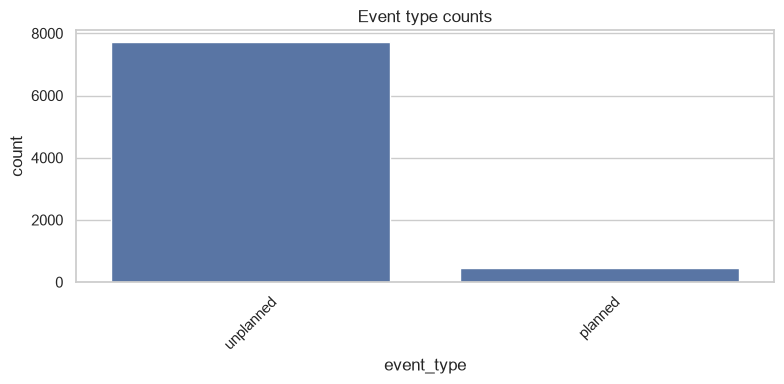

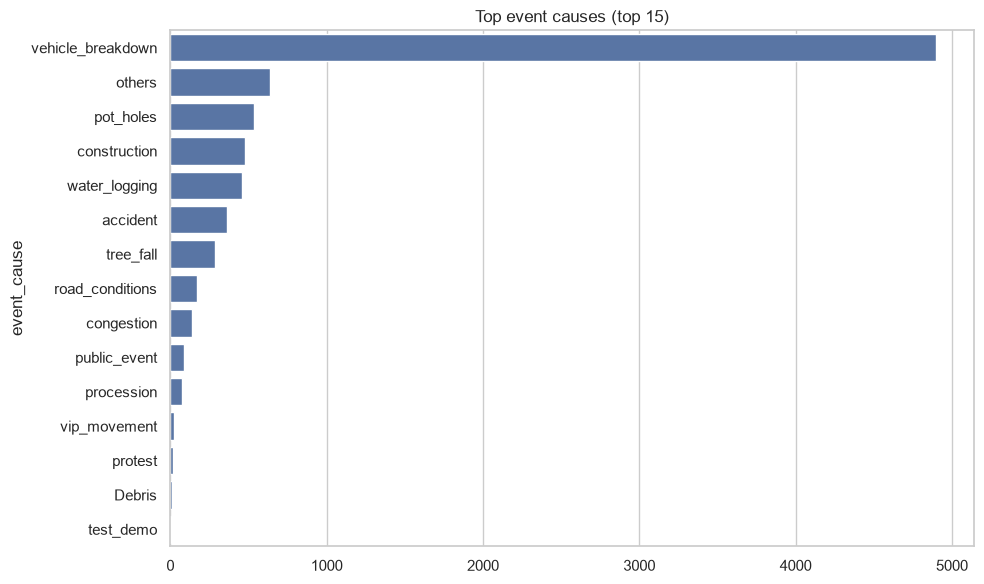

In [5]:
# Event type and cause distributions
plt.figure(figsize=(8,4))
sns.countplot(data=df, x='event_type', order=df['event_type'].value_counts().index)
plt.title('Event type counts')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR,'event_type_counts.png'))

plt.figure(figsize=(10,6))
top_causes = df['event_cause'].value_counts().nlargest(15)
sns.barplot(x=top_causes.values, y=top_causes.index)
plt.title('Top event causes (top 15)')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR,'top_event_causes.png'))


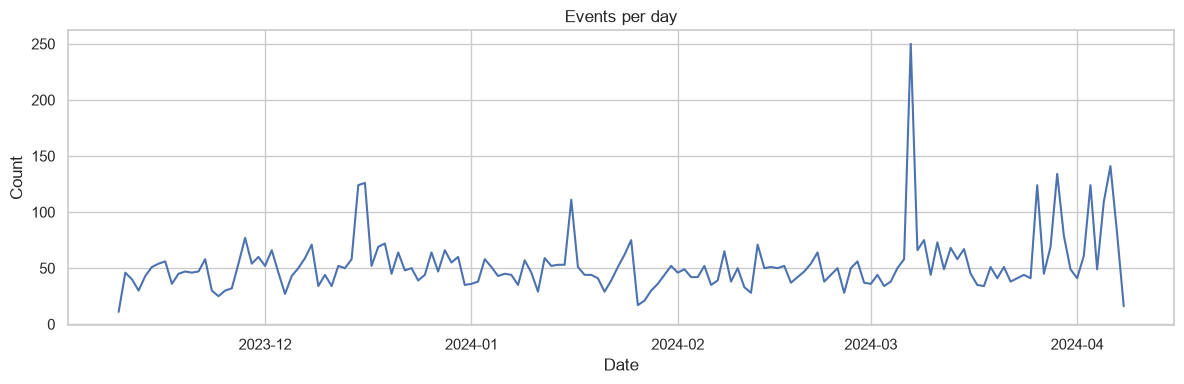

In [6]:
# Time series: events per day
if 'event_date' in df.columns:
    ts = df.groupby('event_date').size()
    plt.figure(figsize=(12,4))
    ts.plot()
    plt.title('Events per day')
    plt.xlabel('Date')
    plt.ylabel('Count')
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR,'events_per_day.png'))
else:
    print('No event_date column available')


In [7]:
# Folium map of events (sample if large)
lat_col = 'latitude'
lon_col = 'longitude'
if lat_col in df.columns and lon_col in df.columns:
    map_center = [df[lat_col].mean(), df[lon_col].mean()]
    m = folium.Map(location=map_center, zoom_start=12)
    mc = MarkerCluster()
    sample = df if len(df)<=5000 else df.sample(3000, random_state=1)
    for _, r in sample.iterrows():
        try:
            popup = f"{r.get('event_cause','')} | status: {r.get('status','')}"
            folium.CircleMarker(location=[r[lat_col], r[lon_col]], radius=4,
                                color='blue', fill=True, popup=popup).add_to(mc)
        except Exception:
            continue
    mc.add_to(m)
    m.save(os.path.join(OUTPUT_DIR,'events_map.html'))
    display("Map saved to notebooks/eda_outputs/events_map.html")
else:
    print('No lat/lon columns')


'Map saved to notebooks/eda_outputs/events_map.html'

In [8]:
# Save basic summaries
summary = {
    'shape': df.shape,
    'event_type_counts': df['event_type'].value_counts().to_dict() if 'event_type' in df.columns else {}
}
import json
with open(os.path.join(OUTPUT_DIR,'summary.json'),'w') as f:
    json.dump(summary, f, indent=2, default=str)

print('Outputs written to', OUTPUT_DIR)


Outputs written to notebooks/eda_outputs


# Next steps and suggested analyses

- Clean and normalize text fields (`description`, `event_cause`), map categories
- Spatial clustering: DBSCAN or H3 hex binning to identify hotspots
- Feature engineering: time-of-day, day-of-week, corridor, priority, requires_road_closure
- Build forecasting model for event counts or impact (short horizon)
- Prototype optimization rules to recommend interventions
